Assignment-**5**

**EDA**

In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [105]:
df = pd.read_csv('/content/Cardiotocographic.csv')

In [106]:
df.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


In [107]:

df.shape

(2126, 14)

In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


In [109]:
df.describe()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
count,2105.000000,2106.000000,2126.000000,2126.000000,2126.000000,2105.000000,2105.000000,2126.000000,2126.000000,2126.000000,2105.000000,2105.000000,2105.000000,2105.000000
mean,133.343598,0.003219,0.009894,0.004391,0.001895,0.000003,0.000175,46.995984,1.364378,10.285964,8.284887,70.429260,0.316371,1.304507
std,11.270154,0.004391,0.067540,0.003340,0.003343,0.000142,0.000840,18.813973,1.173632,21.205041,7.772858,42.931822,0.645622,0.644619
min,51.842487,-0.019284,-0.480634,-0.014925,-0.015393,-0.001353,-0.005348,-63.000000,-6.600000,-91.000000,-50.700000,-174.000000,-3.000000,-1.025988
25%,126.000000,0.000000,0.000000,0.001851,0.000000,0.000000,0.000000,32.000000,0.700000,0.000000,4.600000,37.000000,0.000000,1.000000
50%,133.000000,0.001634,0.000000,0.004484,0.000000,0.000000,0.000000,49.000000,1.200000,0.000000,7.400000,67.000000,0.000000,1.000000
75%,140.000000,0.005650,0.002567,0.006536,0.003289,0.000000,0.000000,61.000000,1.700000,11.000000,10.900000,100.000000,1.000000,1.000000
max,214.000000,0.038567,0.961268,0.030002,0.030769,0.002706,0.010695,162.000000,13.800000,182.000000,101.400000,357.000000,3.000000,5.000000


In [110]:
df.isnull().sum()

,0
LB,21
AC,20
FM,0
UC,0
DL,0
DS,21
DP,21
ASTV,0
MSTV,0
ALTV,0


1

In [111]:
missing_columns = df.columns[df.isnull().any()]

for column in missing_columns:
  df[column] = df[column].fillna(df[column].mean())

In [112]:
df.isnull().sum()

,0
LB,0
AC,0
FM,0
UC,0
DL,0
DS,0
DP,0
ASTV,0
MSTV,0
ALTV,0


In [113]:
df.select_dtypes(include='object').mean()

,0


In [114]:
df.dtypes

,0
LB,float64
AC,float64
FM,float64
UC,float64
DL,float64
DS,float64
DP,float64
ASTV,float64
MSTV,float64
ALTV,float64


In [115]:
df.duplicated().sum()

np.int64(2)

In [116]:
df = df.drop_duplicates()

In [117]:
df.duplicated().sum()

np.int64(0)

In [118]:
numeric_columns = df.select_dtypes(include='number').columns

In [119]:
Q1 = df[numeric_columns].quantile(0.25)
Q3 = df[numeric_columns].quantile(0.75)
IQR = Q3 - Q1

In [120]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [121]:
outliers_counts= ((df[numeric_columns] < lower_bound)
                |(df[numeric_columns] > upper_bound)).sum()
outliers_counts

,0
LB,10
AC,42
FM,347
UC,13
DL,125
DS,141
DP,305
ASTV,10
MSTV,80
ALTV,318


detect outliers

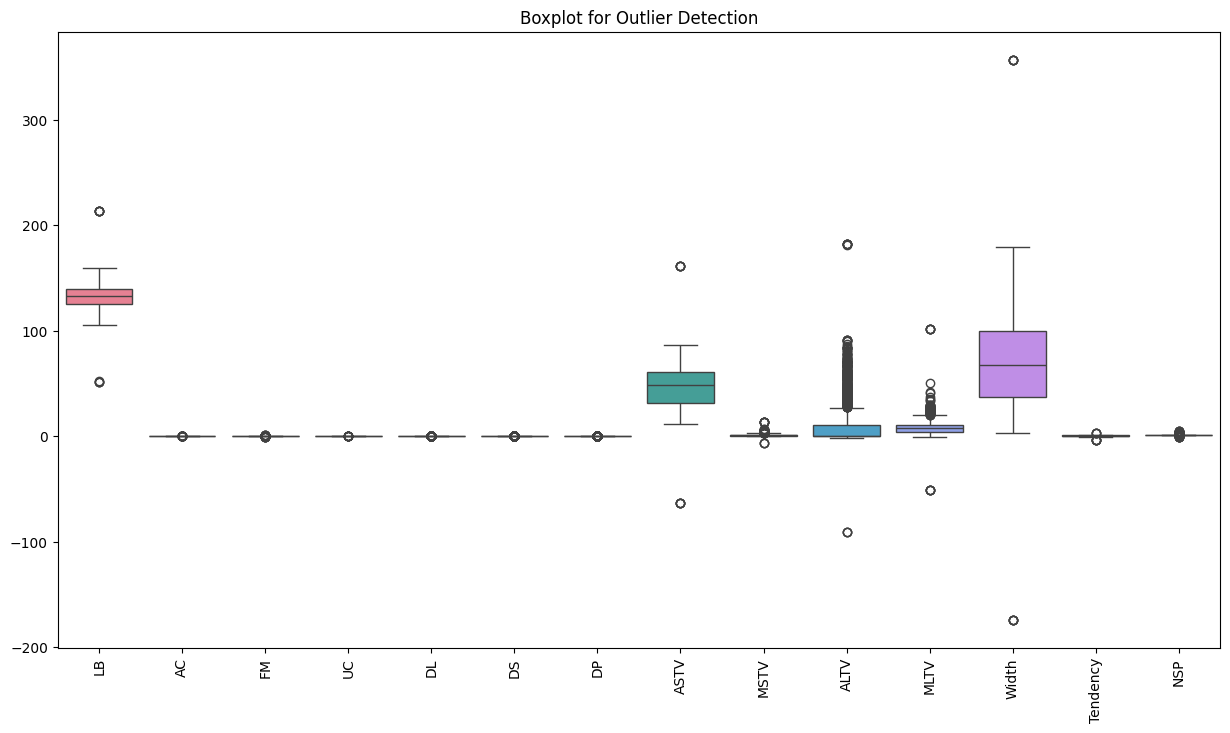

In [122]:
plt.figure(figsize=(15, 8))

sns.boxplot(data=df[numeric_columns])

plt.xticks(rotation=90)
plt.title("Boxplot for Outlier Detection")
plt.show()

treat outliers

In [123]:
df_capped = df.copy()

for column in numeric_columns:
    df_capped[column] = df_capped[column].clip(
        lower=lower_bound[column],
        upper=upper_bound[column]
    )

In [124]:
df_capped.describe()


,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
count,2124.000000,2124.000000,2124.000000,2124.000000,2124.000000,2124.0,2124.0,2124.000000,2124.000000,2124.000000,2124.000000,2124.000000,2124.000000,2124.0
mean,133.292118,0.003148,0.001570,0.004365,0.001772,0.0,0.0,46.998334,1.304554,6.697979,8.011660,70.352452,0.319963,1.0
std,9.926749,0.003827,0.002487,0.003001,0.002670,0.0,0.0,17.609911,0.781303,10.381254,5.046506,39.575996,0.621818,0.0
min,105.000000,-0.008418,-0.003853,-0.005158,-0.004938,0.0,0.0,-11.500000,-0.800000,-16.500000,-4.700000,-57.500000,-1.500000,1.0
25%,126.000000,0.000000,0.000000,0.001858,0.000000,0.0,0.0,32.000000,0.700000,0.000000,4.600000,37.000000,0.000000,1.0
50%,133.000000,0.001668,0.000000,0.004486,0.000000,0.0,0.0,49.000000,1.200000,0.000000,7.500000,68.000000,0.000000,1.0
75%,140.000000,0.005612,0.002568,0.006536,0.003292,0.0,0.0,61.000000,1.700000,11.000000,10.800000,100.000000,1.000000,1.0
max,161.000000,0.014030,0.006421,0.013552,0.008230,0.0,0.0,104.500000,3.200000,27.500000,20.100000,194.500000,2.500000,1.0



2

In [125]:
numeric_columns = df.select_dtypes(include='number').columns

Q1 = df[numeric_columns].quantile(0.25)
Q3 = df[numeric_columns].quantile(0.75)
IQR = Q3 - Q1

summary = {
    'Mean': df[numeric_columns].mean(),
    'Median': df[numeric_columns].median(),
    'Standard Deviation': df[numeric_columns].std(),
    'IQR': IQR
}

summary

{'Mean': LB          133.342039
 AC            0.003220
 FM            0.009904
 UC            0.004394
 DL            0.001897
 DS            0.000003
 DP            0.000175
 ASTV         47.012459
 MSTV          1.364345
 ALTV         10.295650
 MLTV          8.280589
 Width        70.460738
 Tendency      0.316669
 NSP           1.304794
 dtype: float64,
 'Median': LB          133.000000
 AC            0.001668
 FM            0.000000
 UC            0.004486
 DL            0.000000
 DS            0.000000
 DP            0.000000
 ASTV         49.000000
 MSTV          1.200000
 ALTV          0.000000
 MLTV          7.500000
 Width        68.000000
 Tendency      0.000000
 NSP           1.000000
 dtype: float64,
 'Standard Deviation': LB          11.212396
 AC           0.004371
 FM           0.067571
 UC           0.003340
 DL           0.003344
 DS           0.000141
 DP           0.000836
 ASTV        18.812403
 MSTV         1.174084
 ALTV        21.212676
 MLTV         7.736420
 

In [126]:



df[numeric_columns]

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,73.0,0.5,43.000000,2.4,64.0,0.999926,2.000000
1,132.000000,0.006380,0.000000,0.006380,0.003190,0.0,0.0,17.0,2.1,0.000000,10.4,130.0,0.000000,1.000000
2,133.000000,0.003322,0.000000,0.008306,0.003322,0.0,0.0,16.0,2.1,0.000000,13.4,130.0,0.000000,1.000000
3,134.000000,0.002561,0.000000,0.007742,0.002561,0.0,0.0,16.0,2.4,0.000000,23.0,117.0,1.000000,1.000000
4,131.948232,0.006515,0.000000,0.008143,0.000000,0.0,0.0,16.0,2.4,0.000000,19.9,117.0,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2121,140.000000,0.000000,0.961268,0.007426,0.000000,0.0,0.0,79.0,0.2,25.000000,7.2,40.0,0.000000,2.000000
2122,140.000000,0.000775,0.000000,0.006979,0.000000,0.0,0.0,78.0,0.4,22.000000,7.1,66.0,1.000000,2.000000
2123,140.000000,0.000980,0.000000,0.006863,0.000000,0.0,0.0,79.0,0.4,20.000000,6.1,67.0,1.000000,1.990464
2124,140.000000,0.000679,0.000000,0.006110,0.000000,0.0,0.0,78.0,0.4,27.000000,7.0,66.0,1.000000,2.000000


●Highlight any interesting findings from this summary.







The mean and median of some variables are close to each other, indicating similar central values.
Variables with relatively larger standard deviations show greater variability in their observations.
Variables with relatively larger IQR values have a wider spread in their middle 50% of observations.
Noticeable differences between mean and median may indicate skewness or the influence of extreme values.

3.Data Visualization

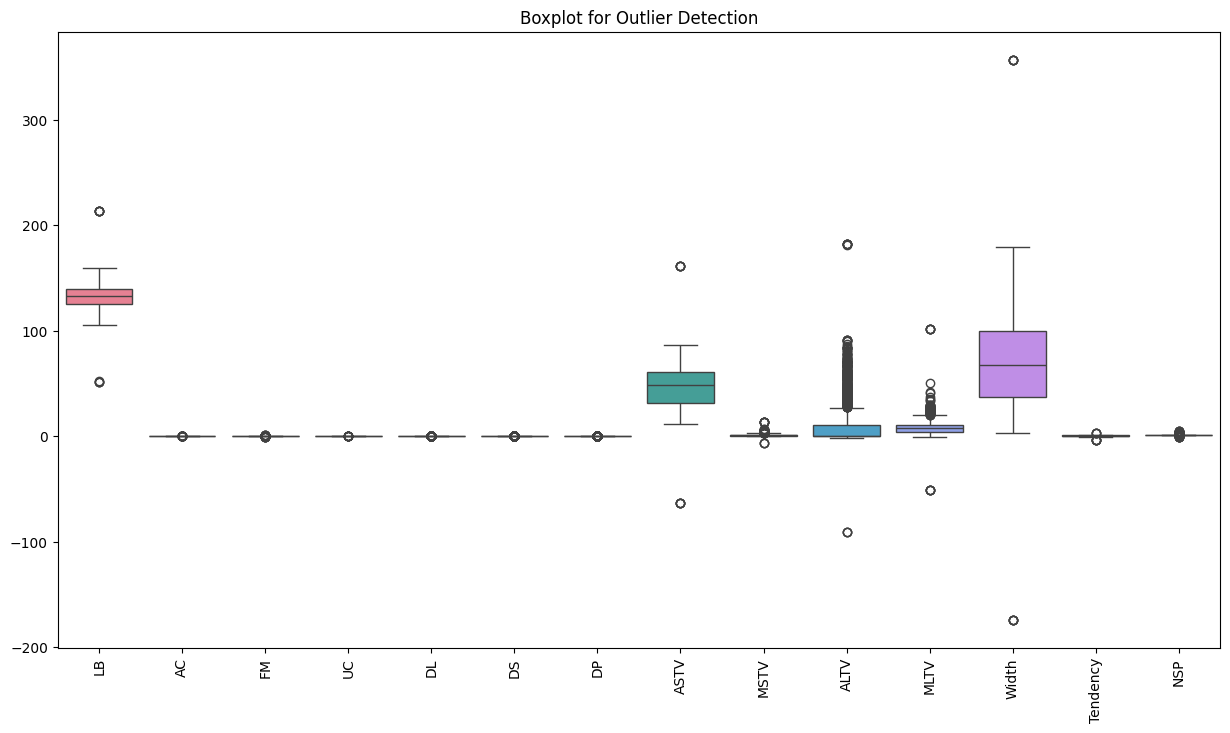

In [127]:
#boxplot
plt.figure(figsize=(15, 8))

sns.boxplot(data=df[numeric_columns])

plt.xticks(rotation=90)
plt.title("Boxplot for Outlier Detection")
plt.show()

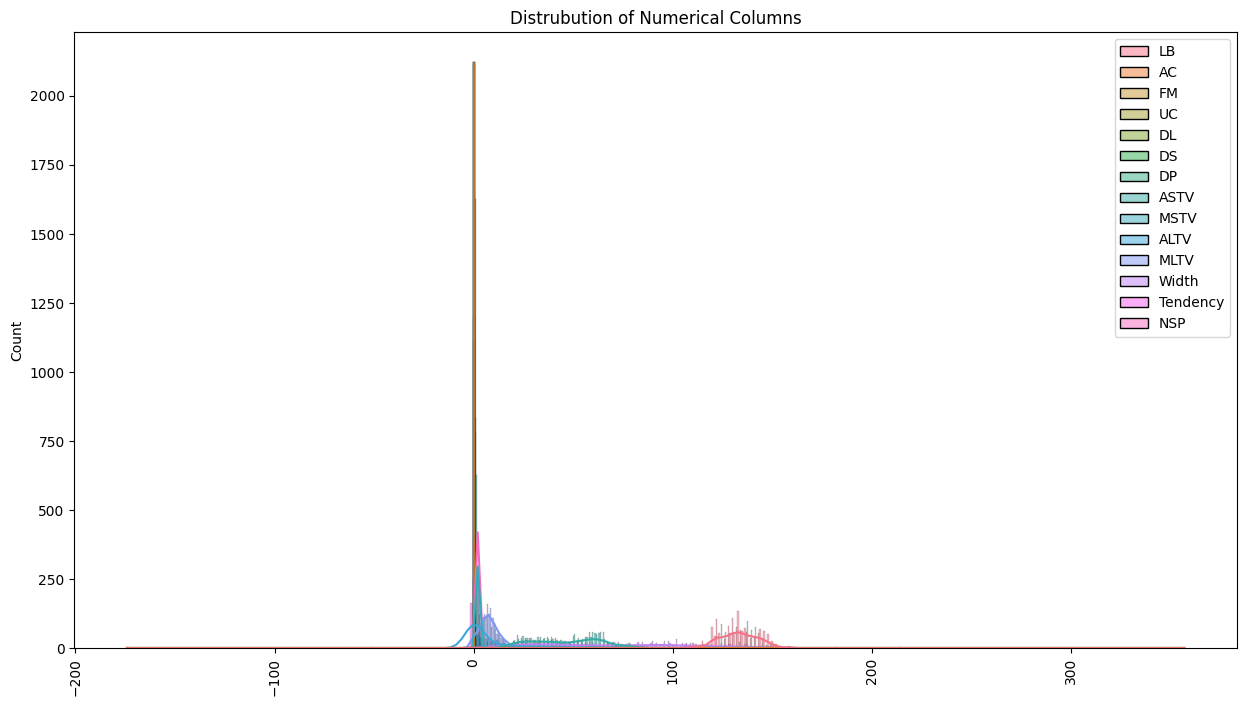

In [128]:
# histo
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(15, 8))

sns.histplot(df[numeric_columns], kde=True)

plt.xticks(rotation=90)
plt.title("Distrubution of Numerical Columns")
plt.show()

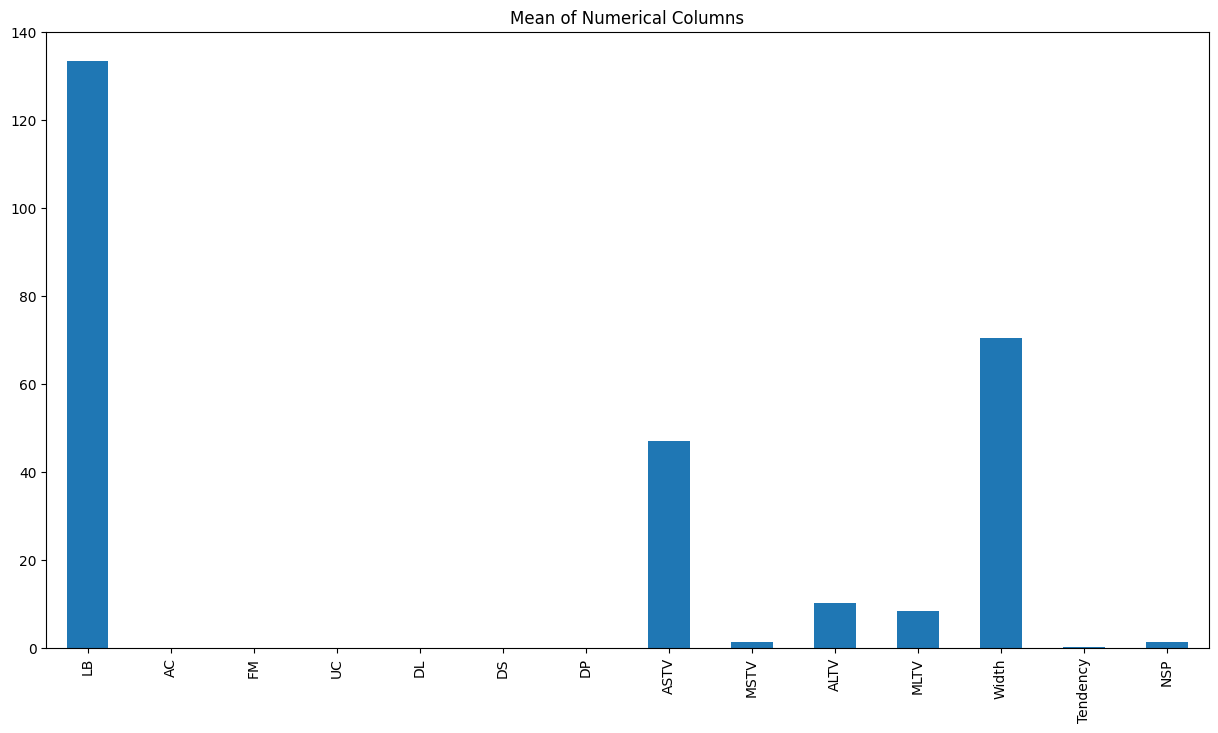

In [129]:
#bar chart
plt.figure(figsize=(15, 8))

df[numeric_columns].mean().plot(kind='bar')

plt.title("Mean of Numerical Columns")
plt.show()


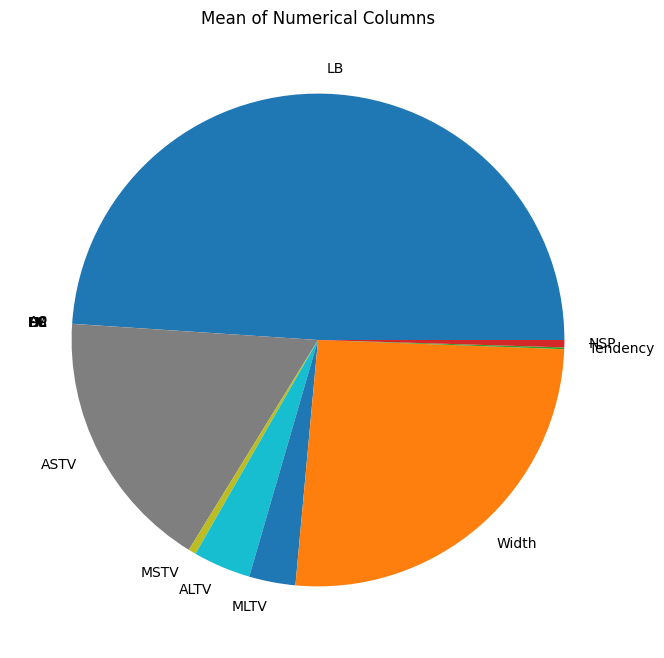

In [130]:

#pie chart
plt.figure(figsize=(15, 8))

df[numeric_columns].mean().plot(kind='pie')

plt.title("Mean of Numerical Columns")
plt.show()



In [131]:
# Find categorical columns
categorical_columns = df.select_dtypes(include='object').columns

print(categorical_columns)

Index([], dtype='object')


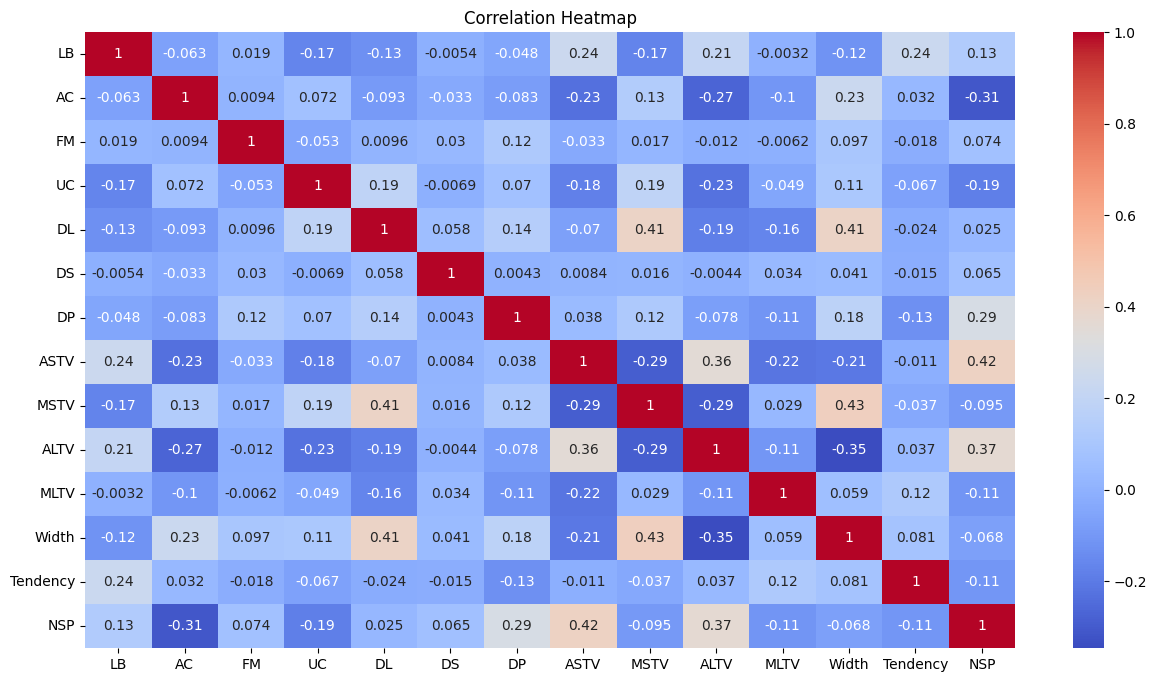

In [132]:
#correlation heatmap`
plt.figure(figsize=(15, 8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

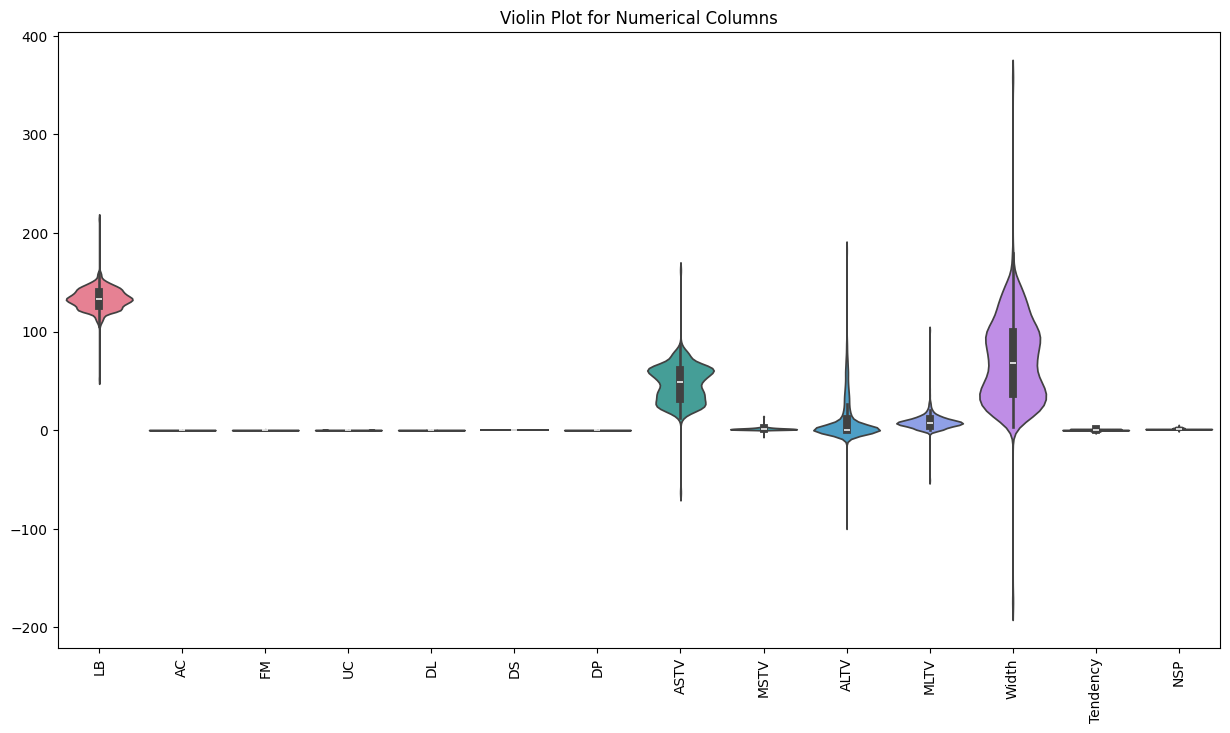

In [133]:
#violin plot
plt.figure(figsize=(15, 8))

sns.violinplot(data=df[numeric_columns])

plt.xticks(rotation=90)
plt.title("Violin Plot for Numerical Columns")
plt.show()

<Figure size 1500x800 with 0 Axes>

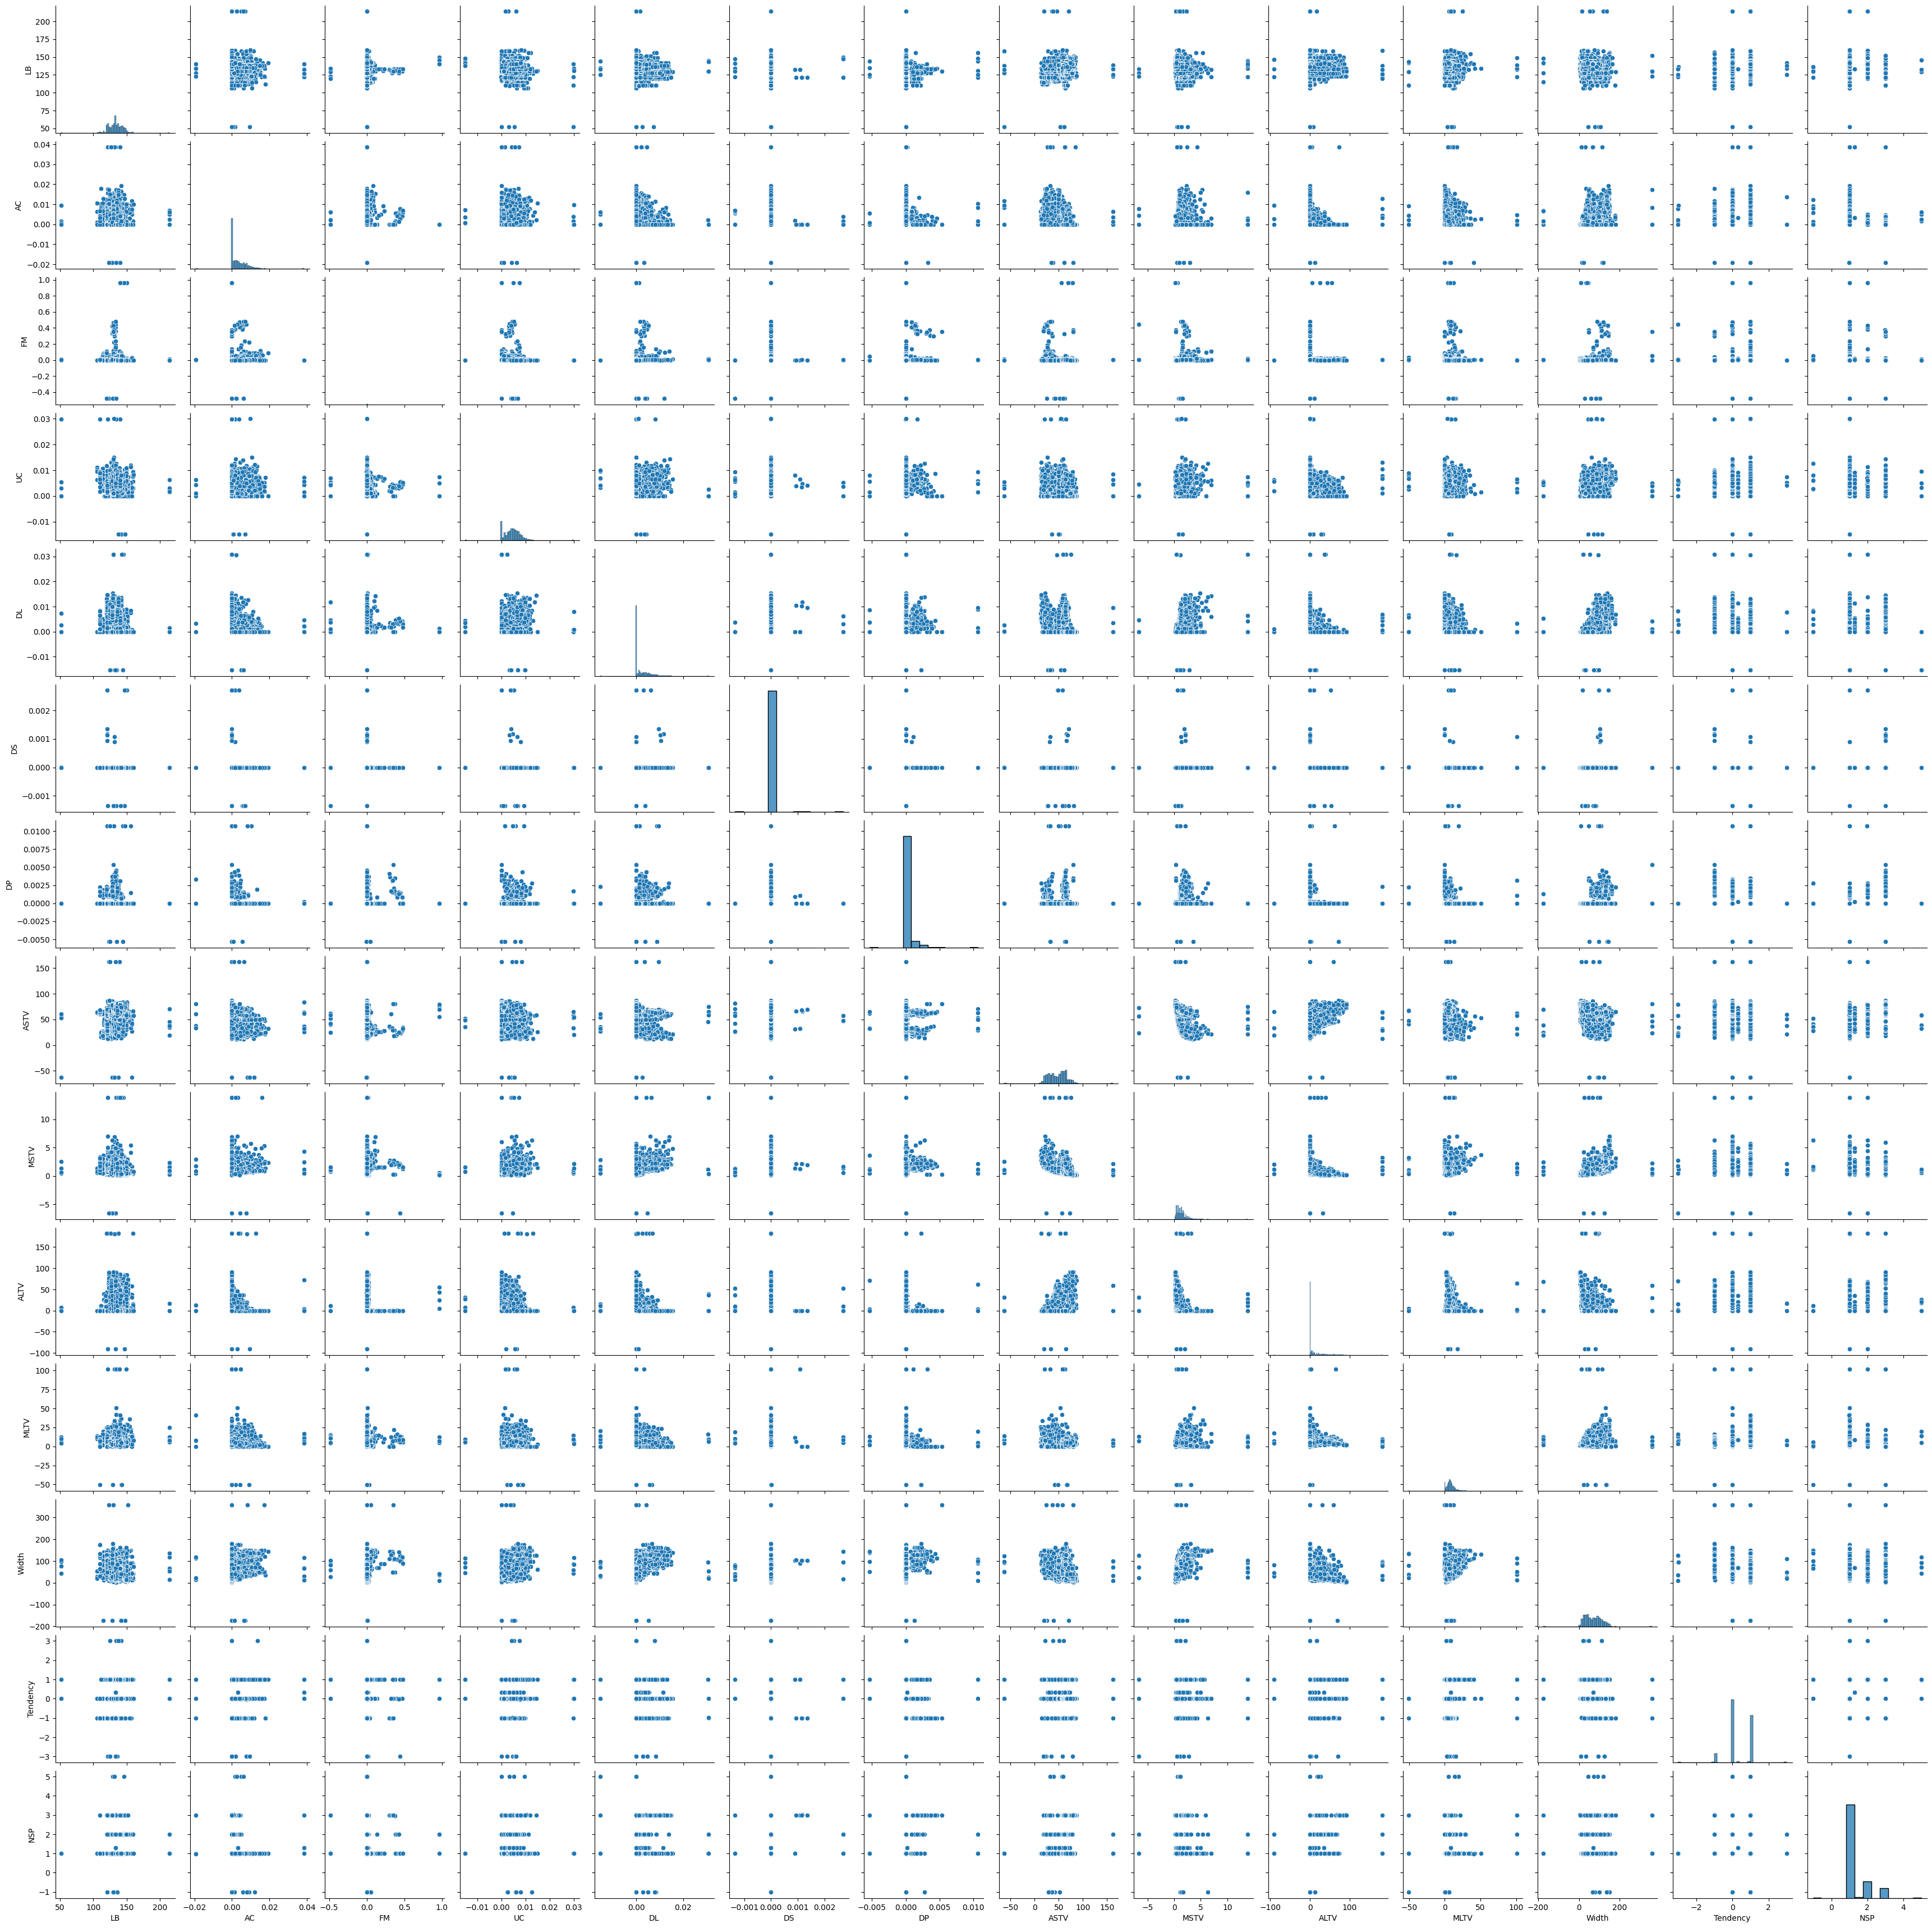

In [134]:
#pair plot
plt.figure(figsize=(15, 8))

sns.pairplot(df[numeric_columns])

plt.show()

4.Pattern Recognition and Insights:

In [135]:
correlation=df[numeric_columns].corr()
print(correlation)

                LB        AC        FM        UC        DL        DS  \
LB        1.000000 -0.063451  0.018808 -0.166642 -0.126557 -0.005439   
AC       -0.063451  1.000000  0.009407  0.071551 -0.093330 -0.033109   
FM        0.018808  0.009407  1.000000 -0.053386  0.009641  0.029896   
UC       -0.166642  0.071551 -0.053386  1.000000  0.189737 -0.006942   
DL       -0.126557 -0.093330  0.009641  0.189737  1.000000  0.058429   
DS       -0.005439 -0.033109  0.029896 -0.006942  0.058429  1.000000   
DP       -0.047726 -0.083331  0.121249  0.070348  0.144853  0.004282   
ASTV      0.241666 -0.231059 -0.032838 -0.182379 -0.069907  0.008414   
MSTV     -0.169224  0.133903  0.017061  0.189685  0.410216  0.016079   
ALTV      0.210672 -0.271203 -0.012005 -0.227881 -0.187275 -0.004400   
MLTV     -0.003225 -0.104655 -0.006157 -0.048754 -0.164941  0.034366   
Width    -0.118375  0.234718  0.097125  0.106550  0.408426  0.040831   
Tendency  0.237112  0.031894 -0.018408 -0.066950 -0.023759 -0.01

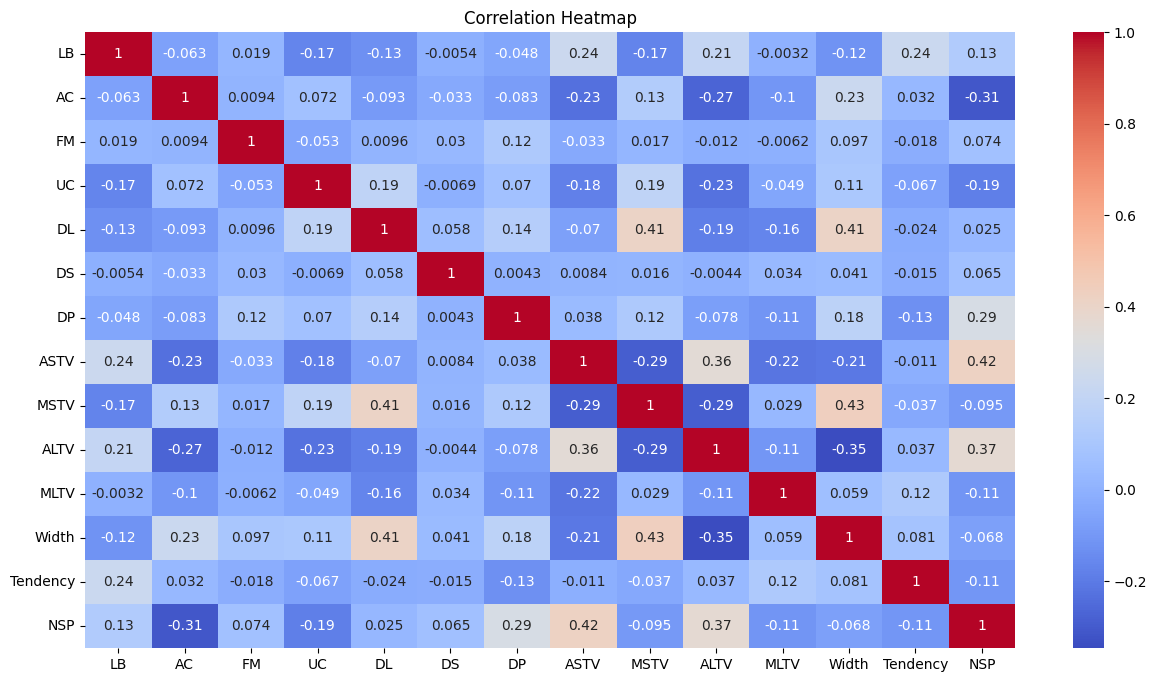

In [136]:
plt.figure(figsize=(15,8))
sns.heatmap(
    df[numeric_columns].corr(),annot =True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [137]:
print(df.dtypes)

LB          float64
AC          float64
FM          float64
UC          float64
DL          float64
DS          float64
DP          float64
ASTV        float64
MSTV        float64
ALTV        float64
MLTV        float64
Width       float64
Tendency    float64
NSP         float64
dtype: object


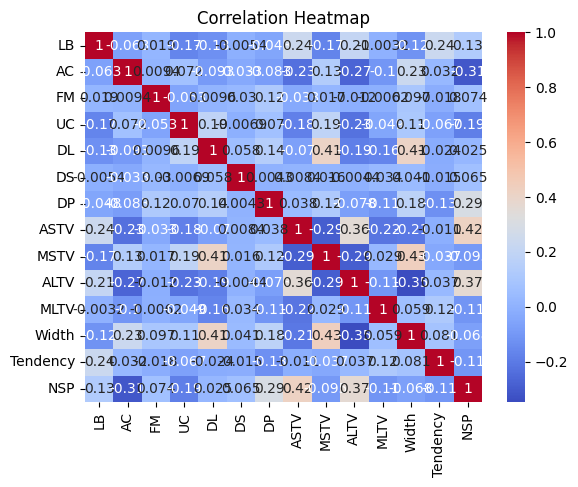

In [138]:
sns.heatmap(
    df[numeric_columns].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

In [139]:
datetime_columns = df.select_dtypes(
    include=['datetime64[ns]', 'datetime64[ns, UTC]']
).columns

if len(datetime_columns) > 0:
    print("Temporal columns found:")
    print(list(datetime_columns))


    for column in datetime_columns:
        df[column] = pd.to_datetime(df[column])

    date_column = datetime_columns[0]
    df = df.sort_values(by=date_column)

    print("\nTemporal data is available.")
    print("Date/Time column used:", date_column)

else:
    print("No temporal data is available in the dataset.")
    print("Therefore, trends or patterns over time cannot be analyzed.")

No temporal data is available in the dataset.
Therefore, trends or patterns over time cannot be analyzed.


5.Conclusion

The exploratory data analysis provided a better understanding of the dataset's structure, distributions, relationships, and patterns. The data was checked for missing values, duplicate records, data types, and outliers. Statistical summaries and visualizations were used to understand the numerical variables and their distributions. Correlation analysis was performed to identify relationships between variables. The dataset does not contain a suitable date/time variable, so trends or patterns over time could not be analyzed.

The insights obtained from the EDA can help in understanding the important characteristics and relationships within the dataset. These findings can support further statistical analysis and machine learning model development. The identified patterns, correlations, and data-quality issues should be considered when selecting variables and preparing the dataset for future analysis.